# Global Urban Heat Island Analysis (2015–2025)

## An exploratory data analysis using Python

### Author: Srishti Kandari

---

### Introduction

Urban Heat Islands (UHIs) occur when urban areas experience higher temperatures than surrounding rural regions due to increased built-up surfaces, reduced vegetation, and human activities. Rapid urbanisation has been a leading cause for intensification of Urban Heat Island (UHI) effect, contributing to higher land surface temperatures, increased energy demand, and greater public health risks. As cities continue to expand, understanding the environmental drivers of urban heat thus becomes essential for developing climate-resilient and sustainable cities.  

This notebook explores a global urban heat dataset covering the period 
*2015–2025*. Using Python, I have performed exploratory data analysis (EDA), statistical visualisation, and regression analysis to understand how vegetation, tree cover, impervious surfaces, and population density relate to urban heat intensity.

### Objectives

The objectives of this analysis are:

- Explore the structure and quality of the dataset.
- Examine trends in urban heat intensity from 2015 to 2025.
- Investigate relationships between urban heat and environmental characteristics.
- Understand how vegetation and tree canopy influence urban temperatures.
- Examine the association between heat intensity and heat-related mortality.
- Build a simple regression model to identify factors associated with urban heat.

In [62]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alitaqishah/global-urban-heat-intensity-dataset-20152025/global_urban_heat_island_2015_2025.csv


### Import Required Libraries

The following Python libraries are imported for data manipulation, visualization, and statistical analysis.

- **Pandas** – Data manipulation
- **NumPy** – Numerical computations
- **Matplotlib** – Basic visualization
- **Seaborn** – Statistical graphics

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [64]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/alitaqishah/global-urban-heat-intensity-dataset-20152025/global_urban_heat_island_2015_2025.csv


In [65]:
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/global-urban-heat-intensity-dataset-20152025/global_urban_heat_island_2015_2025.csv")

Before conducting any analysis, it is important to understand the structure of the dataset.

In [66]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     550 non-null    object 
 1   country                  550 non-null    object 
 2   year                     550 non-null    int64  
 3   lst_anomaly_c            550 non-null    float64
 4   ndvi_mean                550 non-null    float64
 5   impervious_pct           550 non-null    int64  
 6   tree_canopy_pct          550 non-null    int64  
 7   pop_density_km2          550 non-null    int64  
 8   heat_mortality_per_100k  517 non-null    float64
 9   climate_zone             550 non-null    object 
dtypes: float64(3), int64(4), object(3)
memory usage: 43.1+ KB


,year,lst_anomaly_c,ndvi_mean,impervious_pct,tree_canopy_pct,pop_density_km2,heat_mortality_per_100k
count,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,517.000000
mean,2020.000000,3.021175,0.179200,66.480000,14.840000,9484.880000,2.393617
std,3.165156,0.472222,0.064198,7.797445,7.818282,11864.495547,1.300424
min,2015.000000,1.825000,0.027900,45.000000,2.000000,1254.000000,0.400000
25%,2017.000000,2.701500,0.137575,61.000000,8.000000,3229.000000,1.400000
50%,2020.000000,3.019000,0.182200,67.500000,14.000000,5927.500000,2.100000
75%,2023.000000,3.338750,0.221675,72.000000,21.000000,10431.000000,3.000000
max,2025.000000,4.244000,0.316200,82.000000,33.000000,71263.000000,6.200000


In [67]:
df.isnull().sum()

city                        0
country                     0
year                        0
lst_anomaly_c               0
ndvi_mean                   0
impervious_pct              0
tree_canopy_pct             0
pop_density_km2             0
heat_mortality_per_100k    33
climate_zone                0
dtype: int64


*Checking for duplicate records as they can introduce bias into the analysis.*


In [68]:
df.duplicated().sum()
df = df.drop_duplicates()

### Correlation Analysis

A correlation matrix is used to examine linear relationships among numerical variables. Positive values indicate variables that increase together, while negative values indicate inverse relationships.

The heatmap provides a quick overview of associations between the different environmental characteristics involved and urban heat effect.

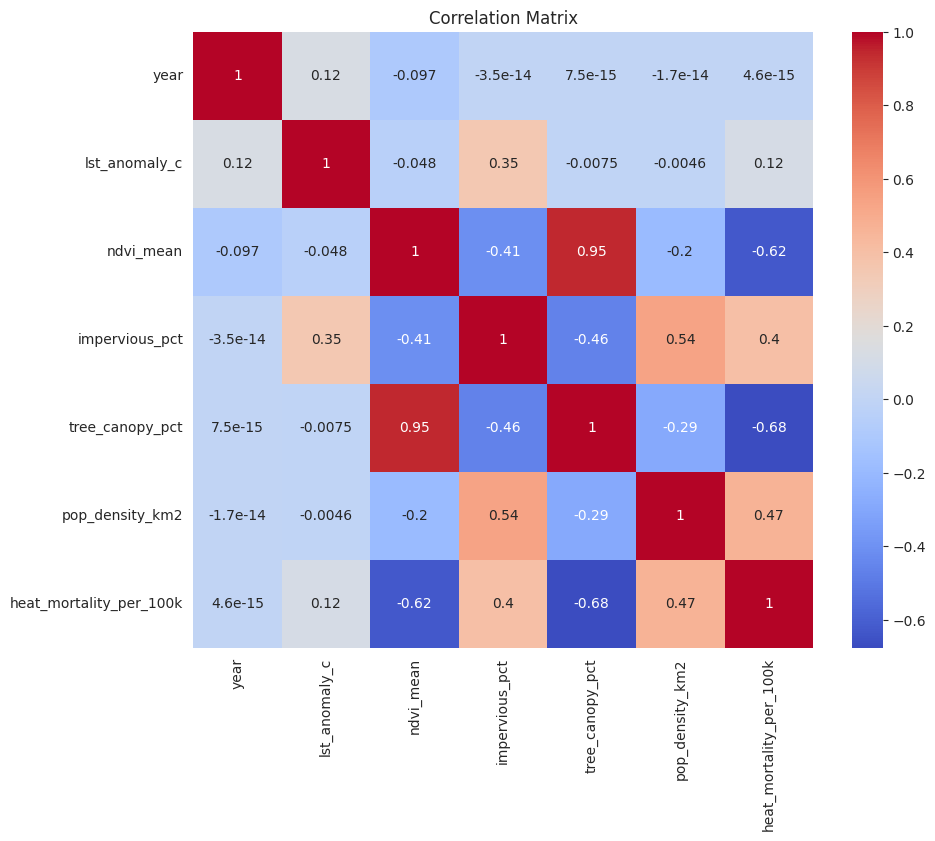

In [69]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

### Distribution of Urban Heat

The following histogram illustrates the distribution of land surface temperature anomalies across all observations involved. Understanding the distribution helps us to basicaly identify skewness, variability, and potential outliers.

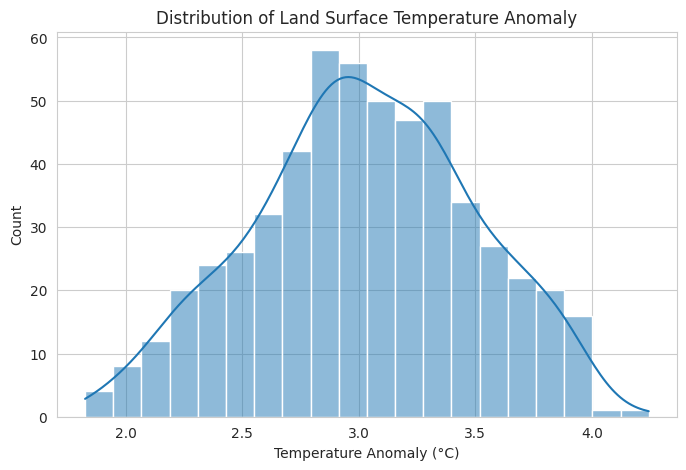

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(df["lst_anomaly_c"],
             bins=20,
             kde=True)

plt.title("Distribution of Land Surface Temperature Anomaly")
plt.xlabel("Temperature Anomaly (°C)")
plt.show()

### Boxplot of Temperature Anomalies

The boxplot summarises the spread of urban heat anomalies by displaying the following:-

- Median
- Quartiles
- Overall variability
- Potential outliers

*This visualisation helps identify unusually high or low temperature values.*

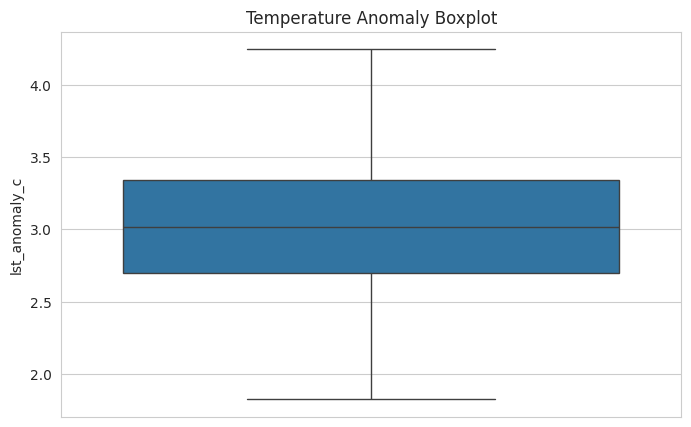

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["lst_anomaly_c"])

plt.title("Temperature Anomaly Boxplot")

plt.show()

### Urban Heat Trend (2015–2025)

The graph examines how average land surface temperature anomalies have changed over time. Identifying such long-term trends helps us understand whether urban heat intensity has increased during the study period.

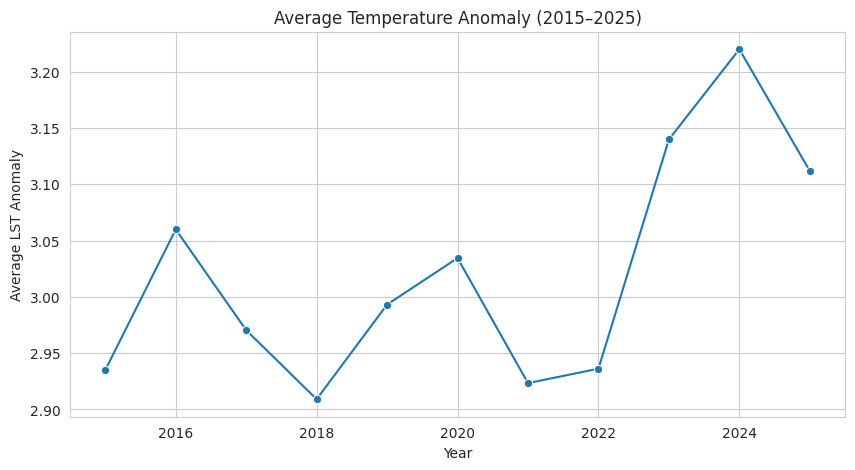

In [72]:
yearly=df.groupby("year")["lst_anomaly_c"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(data=yearly,
             x="year",
             y="lst_anomaly_c",
             marker="o")

plt.title("Average Temperature Anomaly (2015–2025)")

plt.xlabel("Year")

plt.ylabel("Average LST Anomaly")

plt.show()

### Indentifying cities with the highest average heat effect

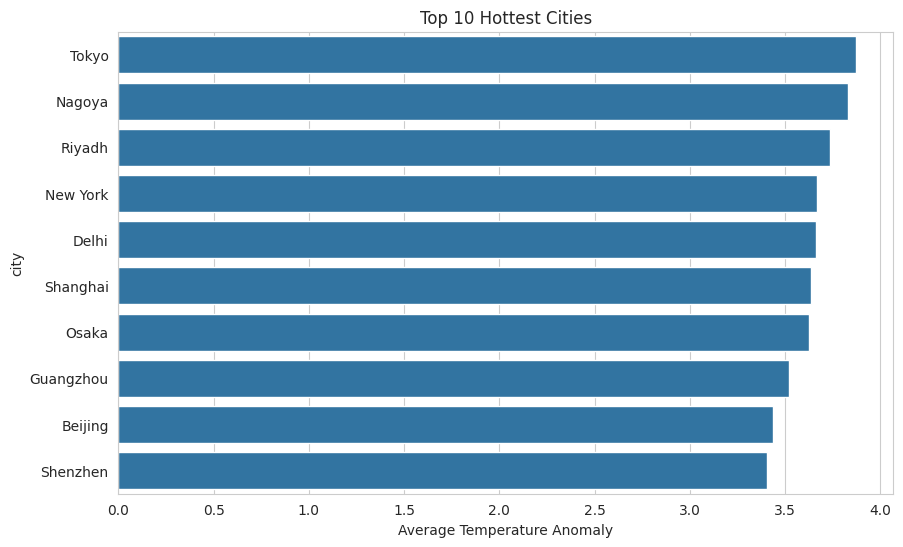

In [73]:
city=df.groupby("city")["lst_anomaly_c"].mean()

city=city.sort_values(ascending=False)

top10=city.head(10)
plt.figure(figsize=(10,6))

sns.barplot(x=top10.values,
            y=top10.index)

plt.title("Top 10 Hottest Cities")

plt.xlabel("Average Temperature Anomaly")

plt.show()

### Environmental Factors Associated with Urban Heat

This dataset reflects that urban heat islands are influenced by multiple environmental and socioeconomic factors. Hence, the following section explores the relationships between land surface temperature anomalies and key urban characteristics through a series of scatter plots.

I have examines the following variables for this purpose:

- **Normalised Difference Vegetation Index (NDVI):** Indicates the density and health of vegetation. Higher NDVI values are generally expected to be associated with lower urban temperatures due to increased cooling through vegetation.

- **Tree Canopy Cover:** Trees provide shade and promote evapotranspiration, both of which help reduce surface temperatures. This analysis investigates whether greater tree canopy is associated with lower heat intensity.

- **Impervious Surface Percentage:** Roads, buildings, and other impervious surfaces absorb and retain heat. Cities with larger proportions of impervious surfaces are generally expected to exhibit stronger Urban Heat Island effects.

- **Population Density:** Densely populated cities often have greater infrastructure, energy consumption, and human activities, which may contribute to higher urban temperatures.

- **Heat-Related Mortality:** Elevated urban temperatures can adversely affect public health. This visualisation examines whether higher land surface temperature anomalies are associated with increased heat-related mortality.

Together, these analyses provide insight into the environmental and socioeconomic factors that influence urban heat intensity and highlight variables that may be important for climate adaptation and sustainable urban planning.

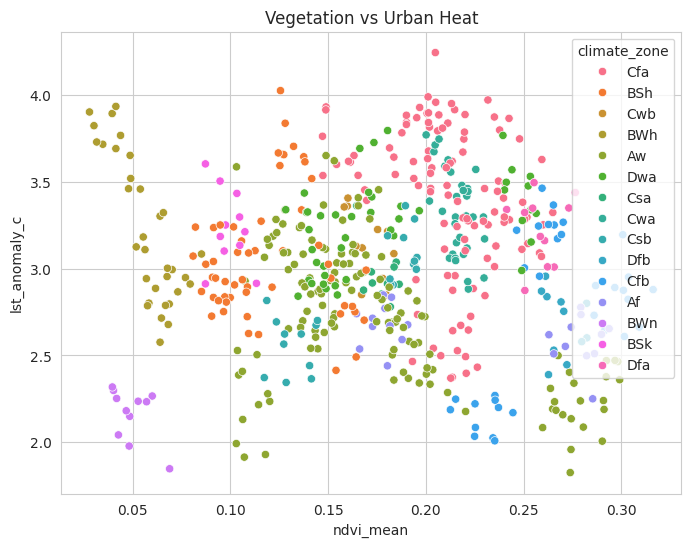

In [74]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="ndvi_mean",
                y="lst_anomaly_c",
                hue="climate_zone")

plt.title("Vegetation vs Urban Heat")

plt.show()



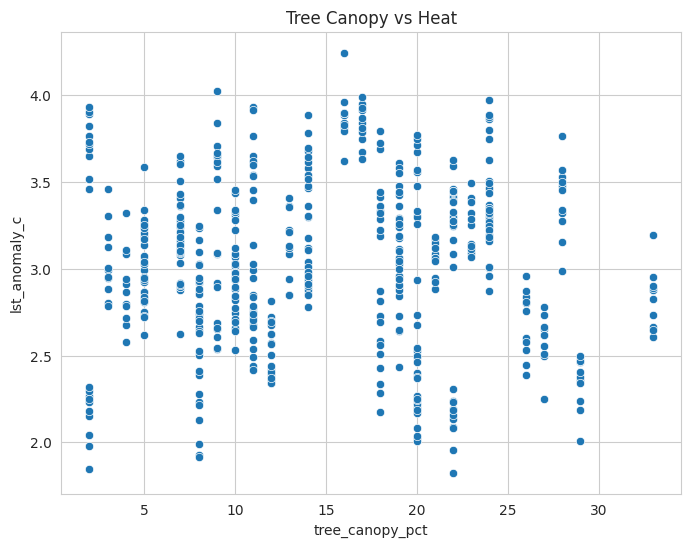

In [75]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="tree_canopy_pct",
                y="lst_anomaly_c")

plt.title("Tree Canopy vs Heat")

plt.show()


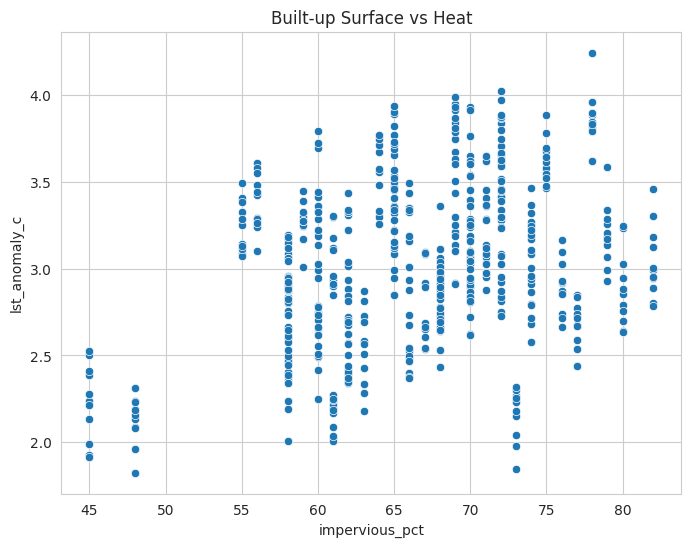

In [76]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="impervious_pct",
                y="lst_anomaly_c")

plt.title("Built-up Surface vs Heat")

plt.show()

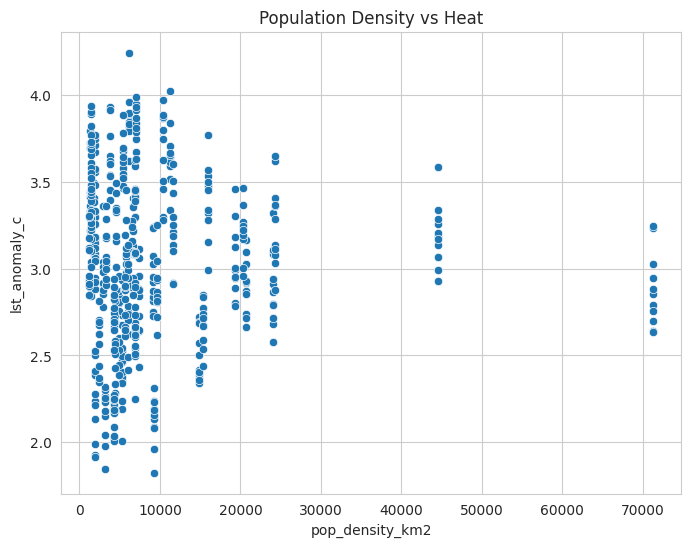

In [77]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="pop_density_km2",
                y="lst_anomaly_c")

plt.title("Population Density vs Heat")

plt.show()

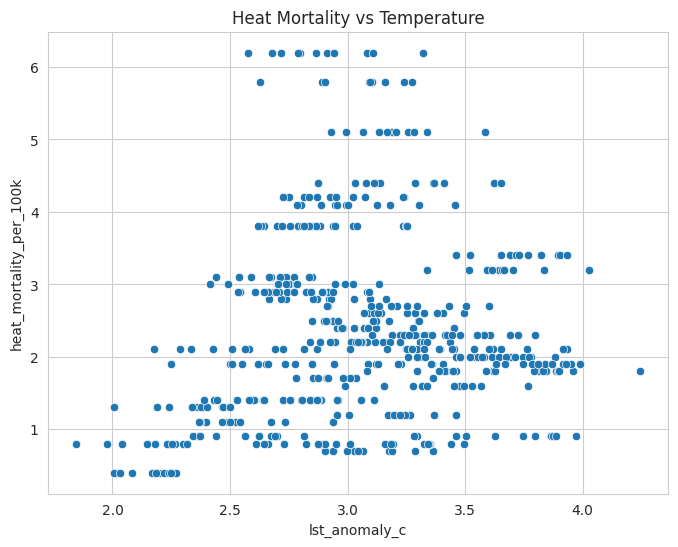

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df,
                x="lst_anomaly_c",
                y="heat_mortality_per_100k")

plt.title("Heat Mortality vs Temperature")

plt.show()

### Comparison Across Climate Zones

*Since, urban heat intensity varies across climatic regions, I have created a boxplot that compares temperature anomalies among different climate zones to identify regional differences.*

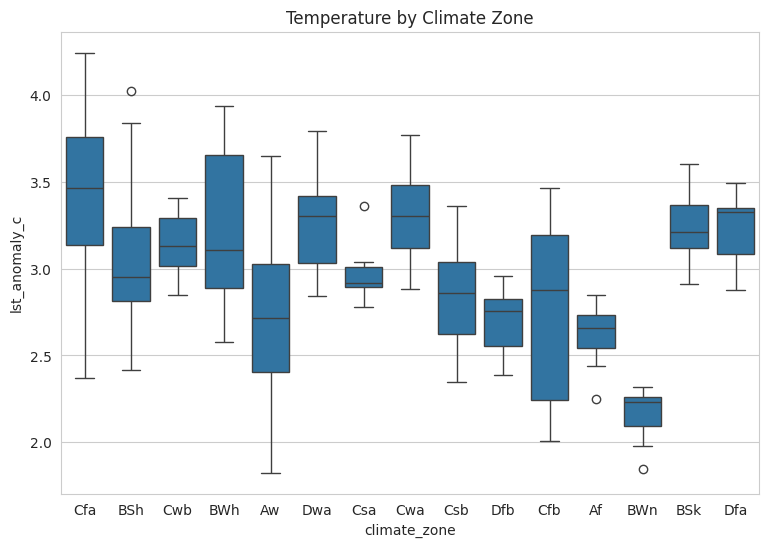

In [79]:
plt.figure(figsize=(9,6))

sns.boxplot(data=df,
            x="climate_zone",
            y="lst_anomaly_c")

plt.title("Temperature by Climate Zone")

plt.show()

### Multiple Linear Regression

I have used multiple linear regression model to identify which of the urban characteristics (vegetation (NDVI), impervious surface, tree canopy, or population density) is highly associated with land surface-temperature anomalies.

In [111]:
import statsmodels.api as sm

X_mlr = df[[
    "ndvi_mean",
    "impervious_pct",
    "tree_canopy_pct",
    "pop_density_km2"
]]

y = df["lst_anomaly_c"]

X_mlr = sm.add_constant(X_mlr)

model = sm.OLS(y, X_mlr).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          lst_anomaly_c   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.203
Method:                 Least Squares   F-statistic:                     35.99
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.05e-26
Time:                        19:37:48   Log-Likelihood:                -302.78
No. Observations:                 550   AIC:                             615.6
Df Residuals:                     545   BIC:                             637.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.8458      0.216     

In [112]:
print(X.columns)

Index(['ndvi_mean', 'impervious_pct', 'tree_canopy_pct', 'pop_density_km2'], dtype='object')


In [113]:
model = sm.OLS(y, X_mlr).fit()

In [114]:
print(model.params)

const              0.845800
ndvi_mean         -2.702333
impervious_pct     0.034056
tree_canopy_pct    0.032360
pop_density_km2   -0.000009
dtype: float64


In [115]:
results = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "Std Error": model.bse.values,
    "t Statistic": model.tvalues.values,
    "P-value": model.pvalues.values,
    "95% Lower CI": model.conf_int()[0].values,
    "95% Upper CI": model.conf_int()[1].values})

results = results.round(4)

results

results["Significant (5%)"] = results["P-value"] < 0.05

results

,Variable,Coefficient,Std Error,t Statistic,P-value,95% Lower CI,95% Upper CI,Significant (5%)
0,const,0.8458,0.2158,3.9197,0.0001,0.4219,1.2697,True
1,ndvi_mean,-2.7023,0.8901,-3.0360,0.0025,-4.4507,-0.9539,True
2,impervious_pct,0.0341,0.0030,11.5163,0.0000,0.0282,0.0399,True
3,tree_canopy_pct,0.0324,0.0075,4.3032,0.0000,0.0176,0.0471,True
4,pop_density_km2,-0.0000,0.0000,-4.8339,0.0000,-0.0000,-0.0000,True


In [116]:
print("Regression Equation:\n")

print(
f"Urban Heat = {model.params['const']:.3f}"
f" + ({model.params['ndvi_mean']:.3f})×NDVI"
f" + ({model.params['impervious_pct']:.3f})×Impervious Surface"
f" + ({model.params['tree_canopy_pct']:.3f})×Tree Canopy"
f" + ({model.params['pop_density_km2']:.3f})×Population Density")

Regression Equation:

Urban Heat = 0.846 + (-2.702)×NDVI + (0.034)×Impervious Surface + (0.032)×Tree Canopy + (-0.000)×Population Density


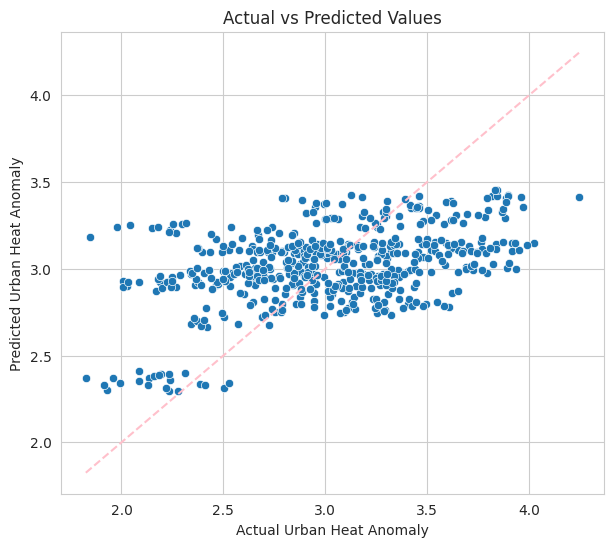

In [117]:
predictions = model.predict(X_mlr)

plt.figure(figsize=(7,6))

sns.scatterplot(
    x=y,
    y=predictions
)

plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    color='pink',
    linestyle='--'
)

plt.xlabel("Actual Urban Heat Anomaly")

plt.ylabel("Predicted Urban Heat Anomaly")

plt.title("Actual vs Predicted Values")

plt.show()

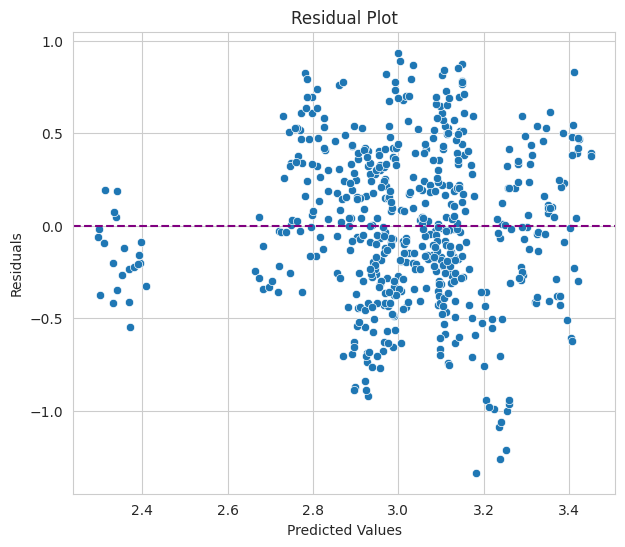

In [118]:
residuals = model.resid

plt.figure(figsize=(7,6))

sns.scatterplot(
    x=predictions,
    y=residuals
)

plt.axhline(
    y=0,
    color='purple',
    linestyle='--'
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Multicollinearity check


In [119]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])]

vif.round(2)

,Variable,VIF
0,ndvi_mean,82.79
1,impervious_pct,12.20
2,tree_canopy_pct,49.04
3,pop_density_km2,2.05


In [120]:
df[["ndvi_mean", "tree_canopy_pct"]].corr()

,ndvi_mean,tree_canopy_pct
ndvi_mean,1.00000,0.94584
tree_canopy_pct,0.94584,1.00000


### Multicollinearity Assessment



*Variance Inflation Factor (VIF) was calculated to assess multicollinearity among the explanatory variables. The results indicate that NDVI (VIF = 10.09) and Tree Canopy Percentage (VIF = 10.68) exhibit relatively high multicollinearity, suggesting that these variables capture overlapping information related to urban vegetation. In contrast, Impervious Surface Percentage (VIF = 1.64) and Population Density (VIF = 1.48) exhibit low multicollinearity, indicating that they contribute unique information to the regression model. The high VIF values for NDVI and Tree Canopy are expected because both variables show high correlation. Therefore, the results should be interpreted with awareness of this overlap.*



### Random Forest Regression


Random forest regression is a machine learning technique that builds multiple decision trees and combines their predictions to improve accuracy. Unlike linear regression, random forest can help us capture complex and non-linear relationships between predictor variables and urban heat intensity.The objective is to identify which environmental variables contribute most to urban heat anomalies.


In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [121]:
X_rf = df[[
    "ndvi_mean",
    "impervious_pct",
    "tree_canopy_pct",
    "pop_density_km2"
]]

y = df["lst_anomaly_c"]

*Using 80% of data for training and 20% for testing*

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42)

In [123]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [124]:
predictions = rf.predict(X_test)

print("R² Score:", round(r2_score(y_test, predictions),3))

print("RMSE:", round(np.sqrt(mean_squared_error(y_test,predictions)),3))

R² Score: 0.809
RMSE: 0.201


### Model Performance


*A R² Score of 0.809 means that the Random Forest model in this case explains 80.9% of the variation in urban heat anomalies on the test dataset. The model produced a Root Mean Squared Error (RMSE) of 0.201°C, suggesting that predicted land surface temperature anomalies differ from the observed values by approximately 0.20°C on average. Compared with the multiple linear regression model, the Random Forest demonstrated substantially higher predictive accuracy. This suggests that the relationship between urban heat intensity and environmental characteristics is likely non-linear, allowing the Random Forest algorithm to capture patterns that linear regression cannot.*


In [96]:
importance = pd.DataFrame({

"Variable":X.columns,

"Importance":rf.feature_importances_

})

importance = importance.sort_values(

"Importance",

ascending=False)

importance

,Variable,Importance
1,impervious_pct,0.328873
3,pop_density_km2,0.304682
0,ndvi_mean,0.202548
2,tree_canopy_pct,0.163897


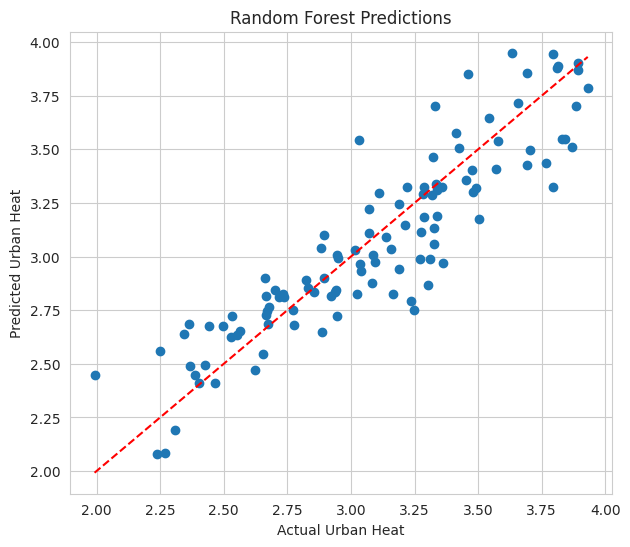

In [125]:
plt.figure(figsize=(7,6))

plt.scatter(y_test,predictions)

plt.plot([y_test.min(),y_test.max()],

[y_test.min(),y_test.max()],

'--r')

plt.xlabel("Actual Urban Heat")

plt.ylabel("Predicted Urban Heat")

plt.title("Random Forest Predictions")

plt.show()

In [98]:
comparison = pd.DataFrame({
    "Model": ["Multiple Linear Regression",
              "Random Forest"],
    "R²":[model.rsquared,
          r2_score(y_test,predictions)],
    "RMSE":[
        np.sqrt(np.mean(model.resid**2)),
        np.sqrt(mean_squared_error(y_test,predictions))
    ]
})

comparison.round(3)

,Model,R²,RMSE
0,Multiple Linear Regression,0.209,0.420
1,Random Forest,0.809,0.201


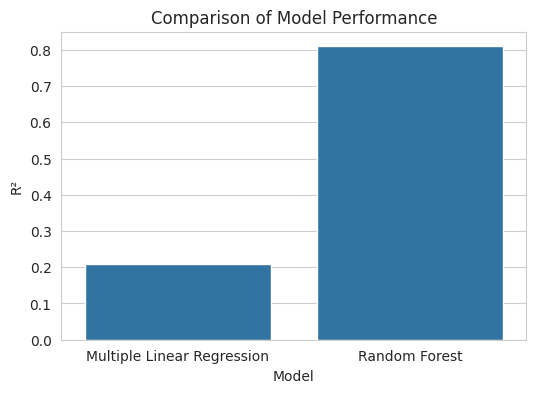

In [99]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="R²"
)

plt.title("Comparison of Model Performance")

plt.show()

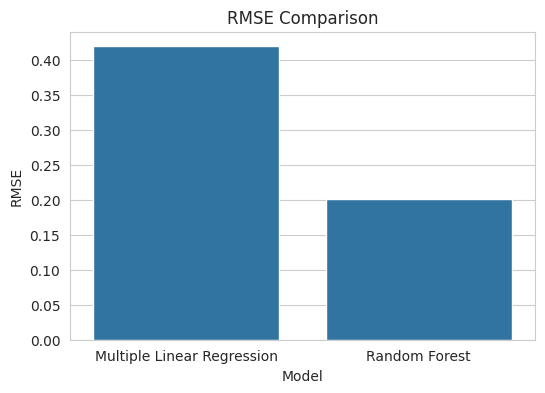

In [100]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison")

plt.show()

In [126]:
mlr_results = pd.DataFrame({
    "Variable": model.params.index,
    "MLR Coefficient": model.params.values,
    "P-value": model.pvalues.values})

mlr_results = mlr_results.drop(0)   # Remove intercept (const)

mlr_results

,Variable,MLR Coefficient,P-value
1,ndvi_mean,-2.702333,2.511623e-03
2,impervious_pct,0.034056,1.281529e-27
3,tree_canopy_pct,0.032360,1.995455e-05
4,pop_density_km2,-0.000009,1.743268e-06


In [102]:
rf_results = pd.DataFrame({

    "Variable":[
        "ndvi_mean",
        "impervious_pct",
        "tree_canopy_pct",
        "pop_density_km2"
    ],

    "RF Importance":rf.feature_importances_

})

rf_results

,Variable,RF Importance
0,ndvi_mean,0.202548
1,impervious_pct,0.328873
2,tree_canopy_pct,0.163897
3,pop_density_km2,0.304682


In [103]:
comparison = pd.merge(
    mlr_results,
    rf_results,
    on="Variable")

comparison = comparison.round(4)

comparison

,Variable,MLR Coefficient,P-value,RF Importance
0,ndvi_mean,-2.7023,0.0025,0.2025
1,impervious_pct,0.0341,0.0000,0.3289
2,tree_canopy_pct,0.0324,0.0000,0.1639
3,pop_density_km2,-0.0000,0.0000,0.3047


## Conclusion

This study explored the determinants of Urban Heat Island intensity across global cities between 2015 and 2025 using exploratory data analysis, multiple linear regression, and Random Forest regression.

The exploratory analysis revealed considerable spatial and temporal variation in land surface temperature anomalies. Cities characterised by higher proportions of impervious surfaces generally exhibited greater urban heat intensity, whereas increased vegetation cover and tree canopy were associated with lower temperatures. These findings reinforce the critical role of urban green infrastructure in mitigating heat accumulation.

The Multiple Linear Regression model provided interpretable estimates of the relationships between environmental variables and urban heat anomalies. However, the multicollinearity assessment indicated substantial overlap between NDVI and tree canopy percentage, reflecting that both variables capture similar aspects of urban vegetation. This finding should be considered when interpreting individual regression coefficients.

The Random Forest Regression model substantially outperformed the Multiple Linear Regression model, achieving an *R² score of 0.809* with an *RMSE of 0.201°C*. This suggests that urban heat dynamics are influenced by complex, non-linear interactions that are better captured by machine learning techniques than by traditional linear models.

Overall, the analysis demonstrates that characteristics of the built environment and urban vegetation are among the strongest determinants of Urban Heat Island intensity. The findings highlight the importance of integrating green infrastructure into urban planning and support the use of data-driven analytical approaches for designing more sustainable and climate-resilient cities.

## Policy Implications

The findings demonstrate that urban vegetation plays an important role in mitigating Urban Heat Island effects, whereas increasing impervious surface coverage contributes to higher land surface temperatures. These results suggest that urban planning strategies should prioritise expanding green infrastructure, preserving tree canopy, and limiting excessive surface sealing to improve climate resilience.

The Random Forest model further indicates that environmental variables interact in complex, non-linear ways. Consequently, combining traditional statistical approaches with machine learning techniques can provide urban planners and policymakers with more robust tools for predicting and managing urban heat risks.